In [ ]:
import sys
print(sys.executable)

In [69]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df= pd.read_csv('C:/Users/David Danell/Desktop/jupyter notebook/data collections/cancer.csv')
df['Diagnosis']= df['Diagnosis'].map({'M': 1, 'B':0})
df= df.drop(columns=['Id'])


print(df.head())
df.info()
print(df.describe())
print(df.shape)
print(df.isna().sum())
print(df.nunique())

   Diagnosis  Radius (mean)  ...  Symmetry (worst)  Fractal dimension (worst)
0          0         13.540  ...            0.2977                    0.07259
1          0         13.080  ...            0.3184                    0.08183
2          0          9.504  ...            0.2450                    0.07773
3          0         13.030  ...            0.1987                    0.06169
4          0          8.196  ...            0.3105                    0.07409

[5 rows x 31 columns]
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Diagnosis                  569 non-null    int64  
 1   Radius (mean)              569 non-null    float64
 2   Texture (mean)             569 non-null    float64
 3   Perimeter (mean)           569 non-null    float64
 4   Area (mean)                569 non-null    float64
 5   Smoothness (mean) 

array([[<Axes: title={'center': 'Diagnosis'}>,
        <Axes: title={'center': 'Radius (mean)'}>,
        <Axes: title={'center': 'Texture (mean)'}>,
        <Axes: title={'center': 'Perimeter (mean)'}>,
        <Axes: title={'center': 'Area (mean)'}>,
        <Axes: title={'center': 'Smoothness (mean)'}>],
       [<Axes: title={'center': 'Compactness (mean)'}>,
        <Axes: title={'center': 'Concavity (mean)'}>,
        <Axes: title={'center': 'Concave points (mean)'}>,
        <Axes: title={'center': 'Symmetry (mean)'}>,
        <Axes: title={'center': 'Fractal dimension (mean)'}>,
        <Axes: title={'center': 'Radius (se)'}>],
       [<Axes: title={'center': 'Texture (se)'}>,
        <Axes: title={'center': 'Perimeter (se)'}>,
        <Axes: title={'center': 'Area (se)'}>,
        <Axes: title={'center': 'Smoothness (se)'}>,
        <Axes: title={'center': 'Compactness (se)'}>,
        <Axes: title={'center': 'Concavity (se)'}>],
       [<Axes: title={'center': 'Concave points 

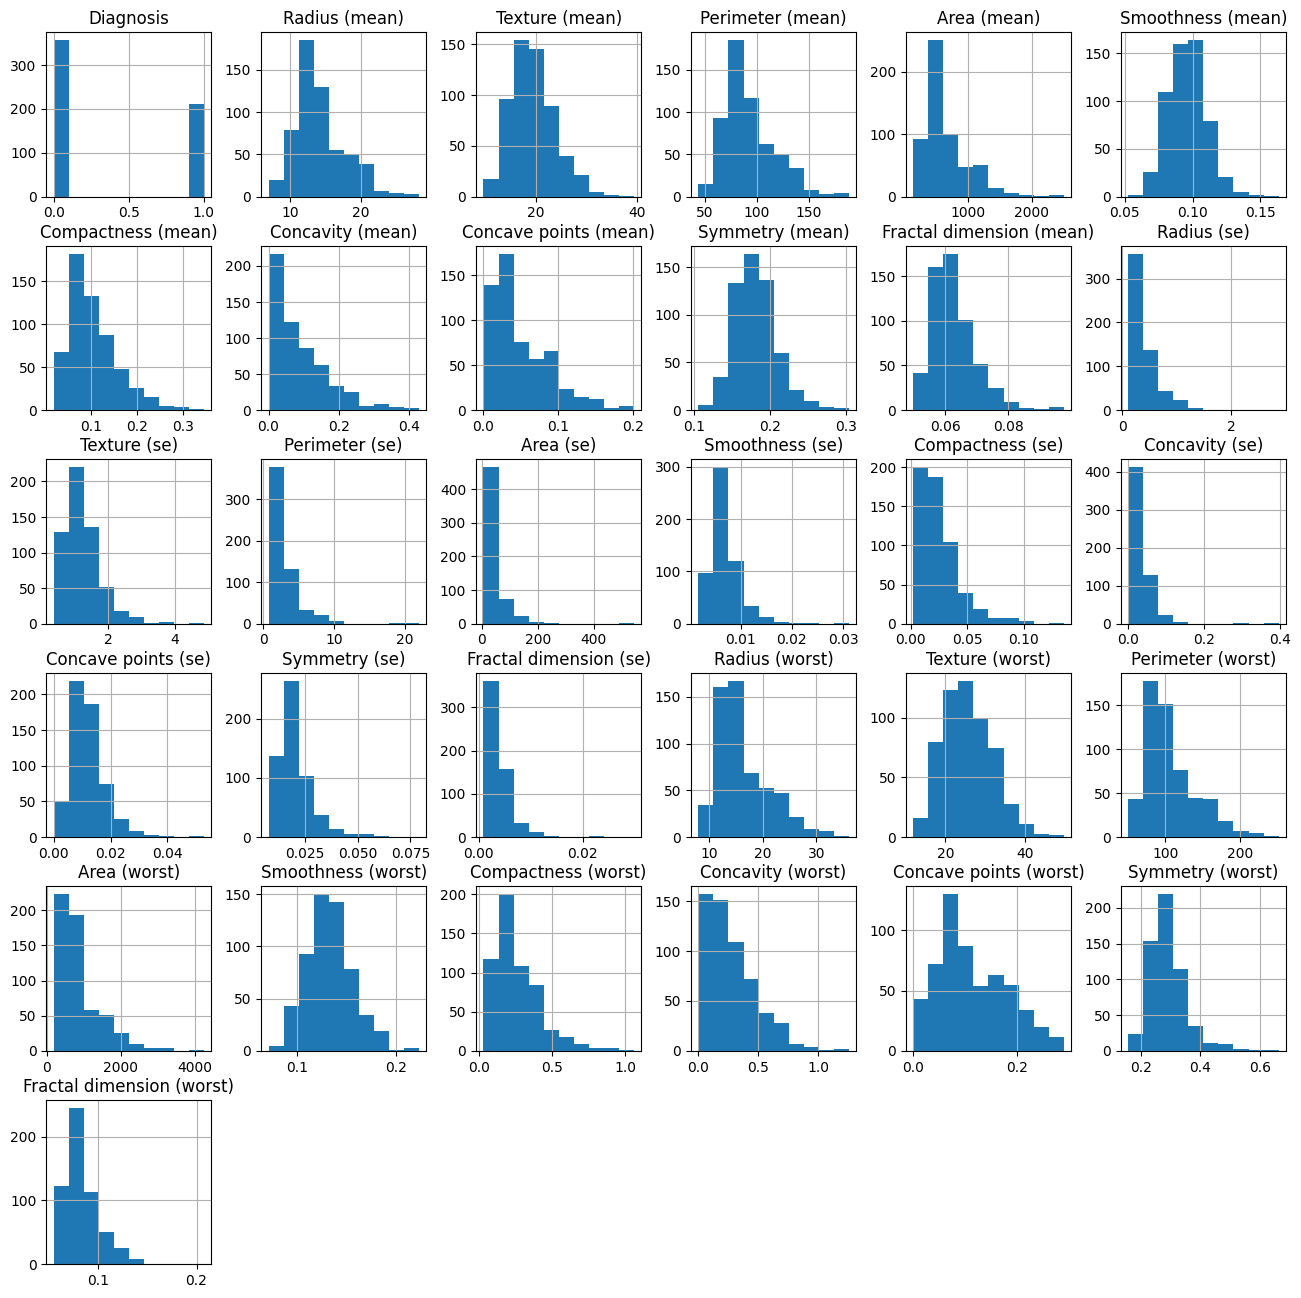

In [70]:

df.hist(figsize=(16,16))


In [75]:
# df_corr= df.corr()

df_corr= df.corr()['Diagnosis'].sort_values(ascending=False)
print(df_corr)

# plt.figure(figsize=(16, 14))
# sns.heatmap(df_corr, annot=True, cmap="coolwarm")
# plt.show()

Diagnosis                    1.000000
Concave points (worst)       0.793566
Perimeter (worst)            0.782914
Concave points (mean)        0.776614
Radius (worst)               0.776454
Perimeter (mean)             0.742636
Area (worst)                 0.733825
Radius (mean)                0.730029
Area (mean)                  0.708984
Concavity (mean)             0.696360
Concavity (worst)            0.659610
Compactness (mean)           0.596534
Compactness (worst)          0.590998
Radius (se)                  0.567134
Perimeter (se)               0.556141
Area (se)                    0.548236
Texture (worst)              0.456903
Smoothness (worst)           0.421465
Symmetry (worst)             0.416294
Texture (mean)               0.415185
Concave points (se)          0.408042
Smoothness (mean)            0.358560
Symmetry (mean)              0.330499
Fractal dimension (worst)    0.323872
Compactness (se)             0.292999
Concavity (se)               0.253730
Fractal dime

In [72]:
X= df.drop(columns=['Diagnosis'])
y= df['Diagnosis']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

model= LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

y_pred= model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


#training score:
train_score=model.score(X_train, y_train)
print('Train score:', train_score)

#test score: 
test_score= model.score(X_test, y_test)
print('Test Score:', test_score)

Accuracy: 0.935672514619883
[[105   2]
 [  9  55]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       107
           1       0.96      0.86      0.91        64

    accuracy                           0.94       171
   macro avg       0.94      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171

Train score: 0.9623115577889447
Test Score: 0.935672514619883


In [ ]:
from sklearn.preprocessing import StandardScaler


X= df.drop(columns=['Diagnosis'])
y= df['Diagnosis']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

#skala
scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#modell
model= LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)


#prediction
y_pred= model.predict(X_test)


#utverdering
# Accuracy = andel korrekta prediktioner totalt
print("Accuracy:", accuracy_score(y_test, y_pred))
# Confusion matrix = visar antal TN, FP, FN, TP
print(confusion_matrix(y_test, y_pred))
# Classification report = precision, recall, f1-score och support per klass
print(classification_report(y_test, y_pred))


#training score:
train_score=model.score(X_train, y_train)
print('Train score:', train_score)

#test score: 
test_score= model.score(X_test, y_test)
print('Test Score:', test_score)

Accuracy: 0.9590643274853801
[[106   1]
 [  6  58]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       107
           1       0.98      0.91      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

Train score: 0.9974874371859297
Test Score: 0.9590643274853801
